In [73]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from pathlib import Path

print("Libraries imported successfully")

Libraries imported successfully


In [74]:
df = sns.load_dataset("titanic")

print("Dataset loaded successfully")
print("Shape:", df.shape)

Dataset loaded successfully
Shape: (891, 15)


In [75]:
df.to_csv("titanic.csv", index=False)

print("Offline fallback saved as titanic.csv")

Offline fallback saved as titanic.csv


In [76]:
print("DATASET INFO")
print("=" * 60)
df.info()

print("\nDATASET DESCRIPTION")
print("=" * 60)
display(df.describe(include="all"))

print("\nDATASET SHAPE")
print("=" * 60)
print(df.shape)

DATASET INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB

DATASET DESCRIPTION


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
count,891.000000,891.000000,891,714.000000,891.000000,891.000000,891.000000,889,891,891,891,203,889,891,891
unique,NaN,NaN,2,NaN,NaN,NaN,NaN,3,3,3,2,7,3,2,2
top,NaN,NaN,male,NaN,NaN,NaN,NaN,S,Third,man,True,C,Southampton,no,True
freq,NaN,NaN,577,NaN,NaN,NaN,NaN,644,491,537,537,59,644,549,537
mean,0.383838,2.308642,NaN,29.699118,0.523008,0.381594,32.204208,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,0.486592,0.836071,NaN,14.526497,1.102743,0.806057,49.693429,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,0.000000,1.000000,NaN,0.420000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,0.000000,2.000000,NaN,20.125000,0.000000,0.000000,7.910400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,0.000000,3.000000,NaN,28.000000,0.000000,0.000000,14.454200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,1.000000,3.000000,NaN,38.000000,1.000000,0.000000,31.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



DATASET SHAPE
(891, 15)


In [77]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

missing_report = pd.DataFrame({
    "missing_count": missing,
    "missing_percentage": missing_pct
})

missing_report = missing_report[
    missing_report["missing_count"] > 0
].sort_values(
    "missing_percentage",
    ascending=False
)

display(missing_report)

,missing_count,missing_percentage
deck,688,77.216611
age,177,19.865320
embarked,2,0.224467
embark_town,2,0.224467


In [78]:
for column in missing_report.index:
    pct = missing_report.loc[column, "missing_percentage"]

    if pct < 5:
        strategy = "Drop rows"
    elif pct <= 30:
        strategy = "Impute"
    else:
        strategy = "Drop column or encode missing as its own category"

    print(
        f"{column}: {pct:.2f}% missing → {strategy}"
    )

deck: 77.22% missing → Drop column or encode missing as its own category
age: 19.87% missing → Impute
embarked: 0.22% missing → Drop rows
embark_town: 0.22% missing → Drop rows


In [79]:
df_clean = df.copy()

# Store the measured missing percentages before cleaning
missing_percentages = (
    df.isnull().mean() * 100
)

# Columns with less than 5% missing → drop affected rows
low_missing_cols = [
    col for col in missing_percentages.index
    if 0 < missing_percentages[col] < 5
]

# Columns with 5%–30% missing → impute
medium_missing_cols = [
    col for col in missing_percentages.index
    if 5 <= missing_percentages[col] <= 30
]

# Columns with more than 30% missing
high_missing_cols = [
    col for col in missing_percentages.index
    if missing_percentages[col] > 30
]

print("Low missing (<5%):", low_missing_cols)
print("Medium missing (5–30%):", medium_missing_cols)
print("High missing (>30%):", high_missing_cols)

Low missing (<5%): ['embarked', 'embark_town']
Medium missing (5–30%): ['age']
High missing (>30%): ['deck']


In [80]:
# 1. Drop rows for columns with <5% missing
if low_missing_cols:
    df_clean = df_clean.dropna(subset=low_missing_cols)

# 2. Impute columns with 5–30% missing
for col in medium_missing_cols:

    if pd.api.types.is_numeric_dtype(df_clean[col]):
        df_clean[col] = df_clean[col].fillna(
            df_clean[col].median()
        )
    else:
        df_clean[col] = df_clean[col].fillna(
            df_clean[col].mode()[0]
        )

# 3. For >30% missing:
# We drop the column because imputing such a large proportion
# would introduce substantial artificial information.
if high_missing_cols:
    df_clean = df_clean.drop(columns=high_missing_cols)

print("Original shape:", df.shape)
print("Cleaned shape:", df_clean.shape)

Original shape: (891, 15)
Cleaned shape: (889, 14)


In [81]:
remaining_missing = df_clean.isnull().sum()

print("Remaining missing values:")
display(
    remaining_missing[remaining_missing > 0]
)

print("\nTotal missing values remaining:",
      df_clean.isnull().sum().sum())

Remaining missing values:


,0



Total missing values remaining: 0


In [82]:
df_clean.to_csv("titanic_cleaned.csv", index=False)

print("Cleaned dataset saved successfully.")
print("Shape:", df_clean.shape)

Cleaned dataset saved successfully.
Shape: (889, 14)


In [83]:
print("Columns:")
print(df_clean.columns.tolist())

print("\nMissing values:")
print(df_clean.isnull().sum())

print("\nShape:")
print(df_clean.shape)

Columns:
['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'embark_town', 'alive', 'alone']

Missing values:
survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64

Shape:
(889, 14)


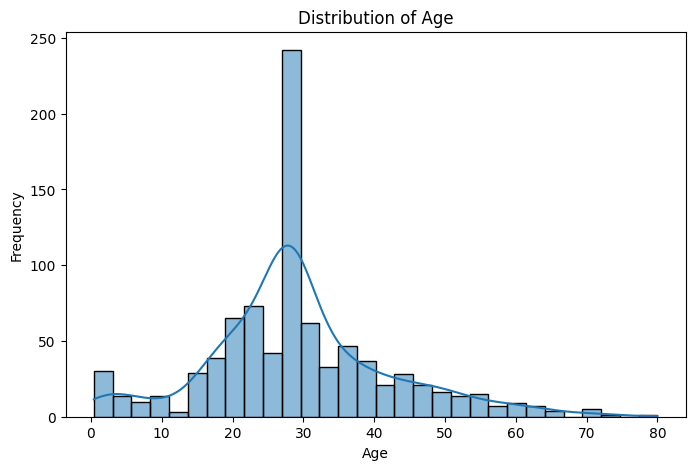

In [84]:
plt.figure(figsize=(8, 5))
sns.histplot(df_clean["age"], bins=30, kde=True)
plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

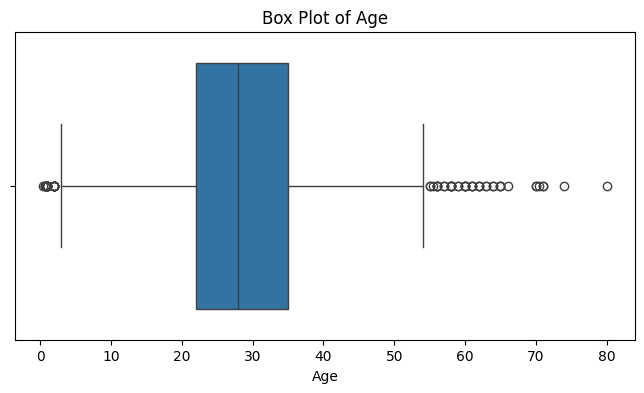

In [85]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=df_clean["age"])
plt.title("Box Plot of Age")
plt.xlabel("Age")
plt.show()

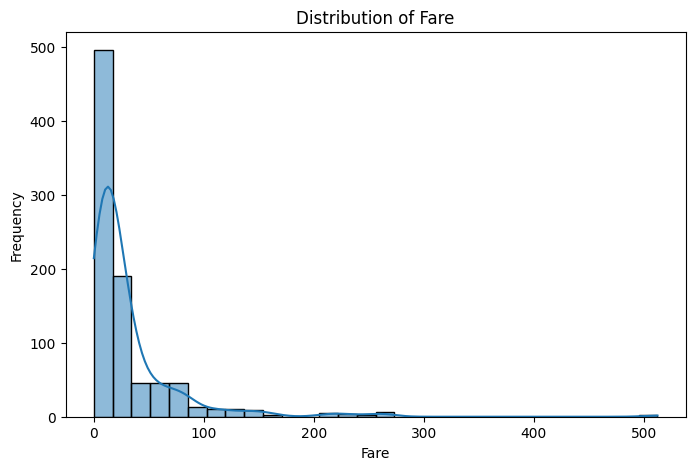

In [86]:
plt.figure(figsize=(8, 5))
sns.histplot(df_clean["fare"], bins=30, kde=True)
plt.title("Distribution of Fare")
plt.xlabel("Fare")
plt.ylabel("Frequency")
plt.show()

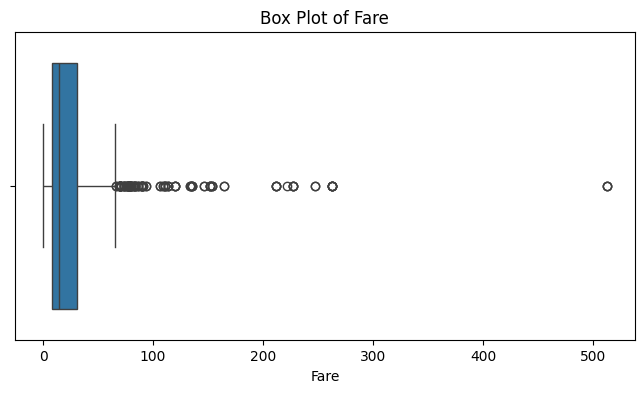

In [87]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=df_clean["fare"])
plt.title("Box Plot of Fare")
plt.xlabel("Fare")
plt.show()

In [88]:
def iqr_outlier_report(series, column_name):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outliers = series[
        (series < lower_bound) |
        (series > upper_bound)
    ]

    print(f"{column_name}")
    print("-" * 40)
    print(f"Q1: {q1:.2f}")
    print(f"Q3: {q3:.2f}")
    print(f"IQR: {iqr:.2f}")
    print(f"Lower bound: {lower_bound:.2f}")
    print(f"Upper bound: {upper_bound:.2f}")
    print(f"Number of outliers: {len(outliers)}")

    return {
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "lower_bound": lower_bound,
        "upper_bound": upper_bound,
        "outlier_count": len(outliers)
    }

age_iqr = iqr_outlier_report(
    df_clean["age"],
    "Age"
)

fare_iqr = iqr_outlier_report(
    df_clean["fare"],
    "Fare"
)

Age
----------------------------------------
Q1: 22.00
Q3: 35.00
IQR: 13.00
Lower bound: 2.50
Upper bound: 54.50
Number of outliers: 65
Fare
----------------------------------------
Q1: 7.90
Q3: 31.00
IQR: 23.10
Lower bound: -26.76
Upper bound: 65.66
Number of outliers: 114


In [89]:
fare_mean = df_clean["fare"].mean()
fare_median = df_clean["fare"].median()
fare_mode = df_clean["fare"].mode()

print("Fare statistics")
print("=" * 40)
print(f"Mean: {fare_mean:.2f}")
print(f"Median: {fare_median:.2f}")
print(f"Mode: {fare_mode.iloc[0]:.2f}")

Fare statistics
Mean: 32.10
Median: 14.45
Mode: 8.05


In [90]:
if fare_mean > fare_median > fare_mode.iloc[0]:
    skew_conclusion = "Fare is right-skewed."
elif fare_mean < fare_median < fare_mode.iloc[0]:
    skew_conclusion = "Fare is left-skewed."
else:
    skew_conclusion = (
        "Fare does not follow a simple mean > median > mode "
        "or mean < median < mode ordering."
    )

print(skew_conclusion)

Fare is right-skewed.


Fare has a mean of 32.10, median of 14.45, and mode of 8.05 . Since the mean is greater than the median, and the distribution has a long upper tail visible in the histogram, the fare distribution is right-skewed.

In [91]:
male_mask = df_clean["sex"] == "male"
female_mask = df_clean["sex"] == "female"

male_survival = df_clean.loc[male_mask, "survived"].mean() * 100
female_survival = df_clean.loc[female_mask, "survived"].mean() * 100

print(f"Male survival rate: {male_survival:.2f}%")
print(f"Female survival rate: {female_survival:.2f}%")

Male survival rate: 18.89%
Female survival rate: 74.04%


In [92]:
first_class_mask = df_clean["pclass"] == 1
second_class_mask = df_clean["pclass"] == 2
third_class_mask = df_clean["pclass"] == 3

first_survival = df_clean.loc[first_class_mask, "survived"].mean() * 100
second_survival = df_clean.loc[second_class_mask, "survived"].mean() * 100
third_survival = df_clean.loc[third_class_mask, "survived"].mean() * 100

print(f"1st class survival rate: {first_survival:.2f}%")
print(f"2nd class survival rate: {second_survival:.2f}%")
print(f"3rd class survival rate: {third_survival:.2f}%")

1st class survival rate: 62.62%
2nd class survival rate: 47.28%
3rd class survival rate: 24.24%


In [93]:
combinations = {
    "Female, 1st class":
        (df_clean["sex"] == "female") & (df_clean["pclass"] == 1),

    "Female, 2nd class":
        (df_clean["sex"] == "female") & (df_clean["pclass"] == 2),

    "Female, 3rd class":
        (df_clean["sex"] == "female") & (df_clean["pclass"] == 3),

    "Male, 1st class":
        (df_clean["sex"] == "male") & (df_clean["pclass"] == 1),

    "Male, 2nd class":
        (df_clean["sex"] == "male") & (df_clean["pclass"] == 2),

    "Male, 3rd class":
        (df_clean["sex"] == "male") & (df_clean["pclass"] == 3)
}

for name, mask in combinations.items():
    rate = df_clean.loc[mask, "survived"].mean() * 100
    print(f"{name}: {rate:.2f}%")

Female, 1st class: 96.74%
Female, 2nd class: 92.11%
Female, 3rd class: 50.00%
Male, 1st class: 36.89%
Male, 2nd class: 15.74%
Male, 3rd class: 13.54%


In [94]:
sex_summary = (
    df_clean.groupby("sex")["survived"]
    .mean()
    .mul(100)
    .round(2)
    .reset_index(name="survival_rate_percent")
)

pclass_summary = (
    df_clean.groupby("pclass")["survived"]
    .mean()
    .mul(100)
    .round(2)
    .reset_index(name="survival_rate_percent")
)

sex_pclass_summary = (
    df_clean.groupby(["sex", "pclass"])["survived"]
    .mean()
    .mul(100)
    .round(2)
    .reset_index(name="survival_rate_percent")
)

print("Survival by Sex")
display(sex_summary)

print("Survival by Pclass")
display(pclass_summary)

print("Survival by Sex + Pclass")
display(sex_pclass_summary)

Survival by Sex


,sex,survival_rate_percent
0,female,74.04
1,male,18.89


Survival by Pclass


,pclass,survival_rate_percent
0,1,62.62
1,2,47.28
2,3,24.24


Survival by Sex + Pclass


,sex,pclass,survival_rate_percent
0,female,1,96.74
1,female,2,92.11
2,female,3,50.00
3,male,1,36.89
4,male,2,15.74
5,male,3,13.54


In [95]:
corr_columns = [
    "survived",
    "pclass",
    "age",
    "sibsp",
    "parch",
    "fare"
]

corr_matrix = df_clean[corr_columns].corr()

display(corr_matrix)

,survived,pclass,age,sibsp,parch,fare
survived,1.000000,-0.335549,-0.069822,-0.034040,0.083151,0.255290
pclass,-0.335549,1.000000,-0.336512,0.081656,0.016824,-0.548193
age,-0.069822,-0.336512,1.000000,-0.232543,-0.171485,0.093707
sibsp,-0.034040,0.081656,-0.232543,1.000000,0.414542,0.160887
parch,0.083151,0.016824,-0.171485,0.414542,1.000000,0.217532
fare,0.255290,-0.548193,0.093707,0.160887,0.217532,1.000000


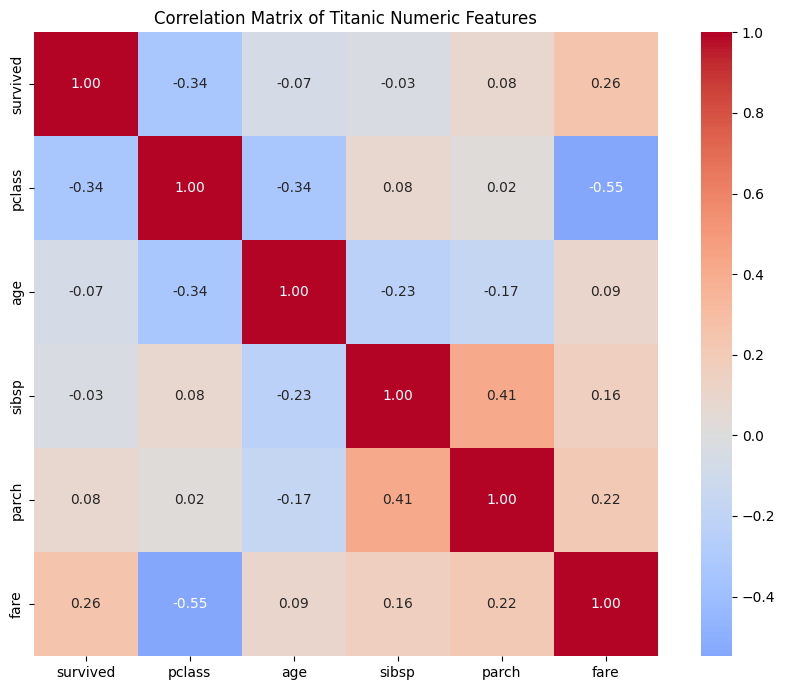

In [96]:
plt.figure(figsize=(9, 7))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True
)

plt.title("Correlation Matrix of Titanic Numeric Features")
plt.tight_layout()
plt.show()

In [97]:
corr_pairs = []

for i in range(len(corr_columns)):
    for j in range(i + 1, len(corr_columns)):
        col1 = corr_columns[i]
        col2 = corr_columns[j]
        corr_value = corr_matrix.loc[col1, col2]

        corr_pairs.append({
            "feature_1": col1,
            "feature_2": col2,
            "correlation": corr_value,
            "absolute_correlation": abs(corr_value)
        })

strongest_correlations = (
    pd.DataFrame(corr_pairs)
    .sort_values(
        "absolute_correlation",
        ascending=False
    )
    .head(2)
    .reset_index(drop=True)
)

display(strongest_correlations)

,feature_1,feature_2,correlation,absolute_correlation
0,pclass,fare,-0.548193,0.548193
1,sibsp,parch,0.414542,0.414542


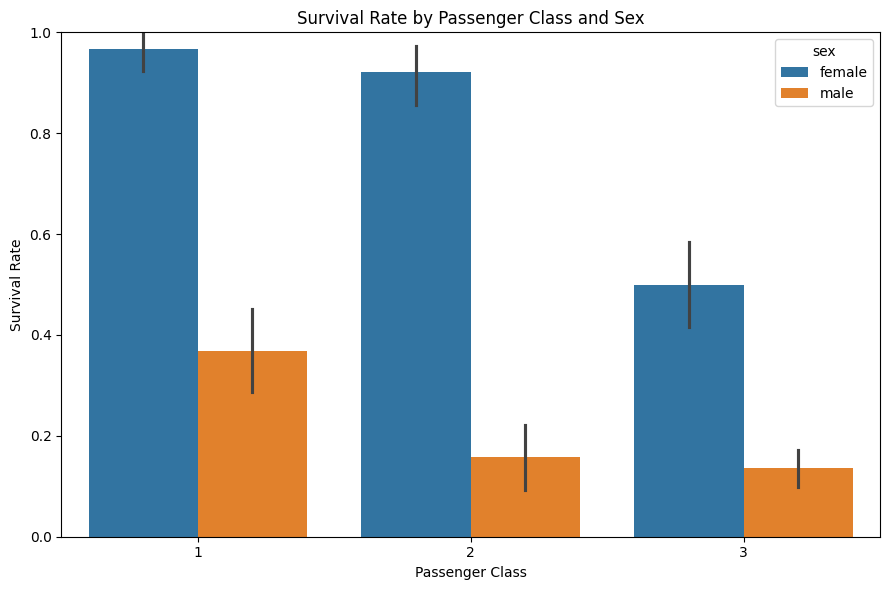

In [98]:
plt.figure(figsize=(9, 6))

sns.barplot(
    data=df_clean,
    x="pclass",
    y="survived",
    hue="sex"
)

plt.title("Survival Rate by Passenger Class and Sex")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

Survival rates vary substantially by both sex and passanger class. Female passangers generally had higher survival rates than male passangers within the same class. First-class passangers also tended to have better survival outcomes than passangers in lower classes, suggesting that both se and socioeconomic position were associated with survival.

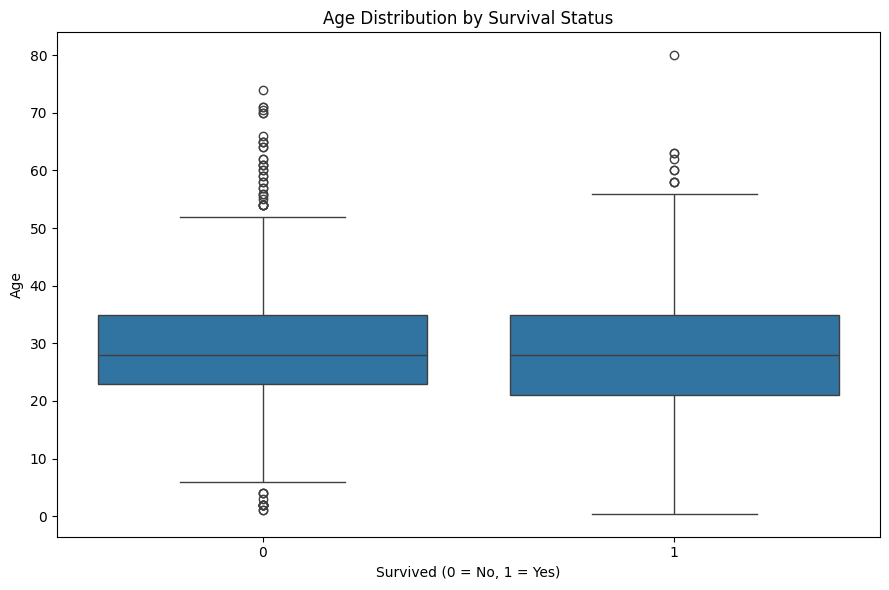

In [99]:
plt.figure(figsize=(9, 6))

sns.boxplot(
    data=df_clean,
    x="survived",
    y="age"
)

plt.title("Age Distribution by Survival Status")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Age")
plt.tight_layout()
plt.show()

The age distributions of survivors and non-survivors overlap considerably, but their medians and spreads can differ. Younger passangers appear in both groups, while the non-survivor group contains wider range of ages this indicates that age alone does not completely explain survival.

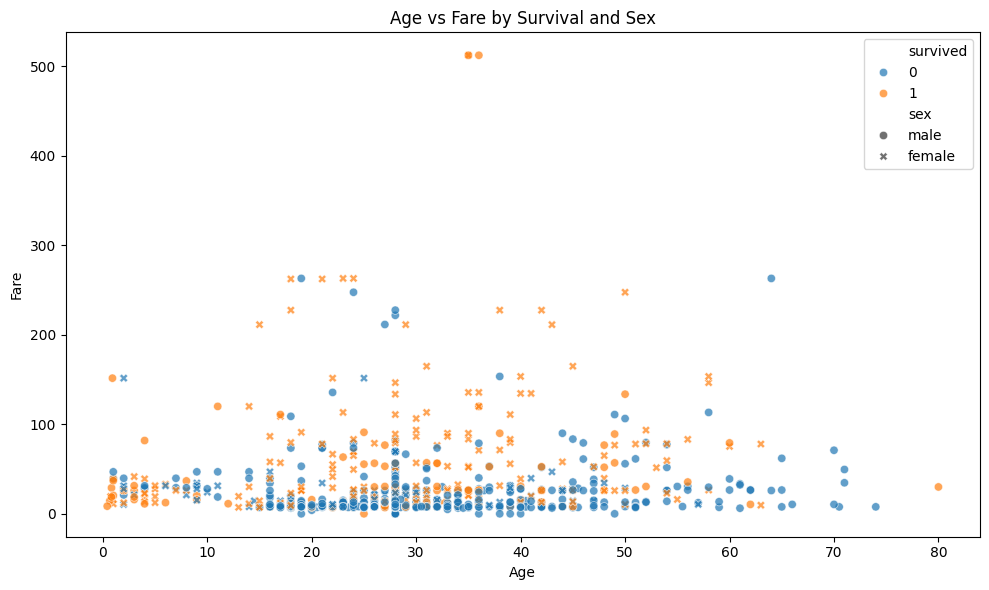

In [100]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_clean,
    x="age",
    y="fare",
    hue="survived",
    style="sex",
    alpha=0.7
)

plt.title("Age vs Fare by Survival and Sex")
plt.xlabel("Age")
plt.ylabel("Fare")
plt.tight_layout()
plt.show()

Fare varies substantially across passengers and tends to be higher for passangers associated with higher-class travel. the plot also shows the survival is not determined by age or fare alone, although higher-fare passengers appear in different survival patterns than lower-fare passangers. the combination of fare, age, and se provides more information than any single variable in isolation.

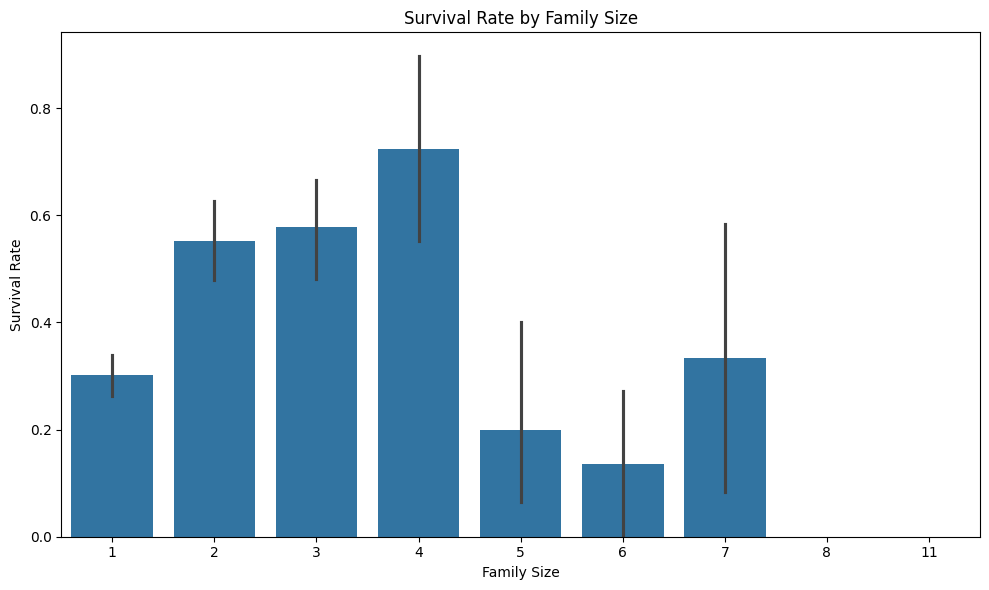

In [103]:
df_clean["family_size"] = (
    df_clean["sibsp"] +
    df_clean["parch"] +
    1
)
plt.figure(figsize=(10, 6))

sns.barplot(
    data=df_clean,
    x="family_size",
    y="survived"
)

plt.title("Survival Rate by Family Size")
plt.xlabel("Family Size")
plt.ylabel("Survival Rate")
plt.tight_layout()
plt.show()

Survival rates vary with family size rather than increasing consistently with the number of relatives onboard. Passengers traveling alone and those in larger family groups can have different survival patterns. This suggests that family structure may provide useful predictive information, although it should be interpreted together with variables such as sex and passenger class.